# Exploratory Data Analysis (Part 2) - Post-Preprocessing

After running our automated preprocessing pipeline (`poetry run task preprocess`), we have generated `data/processed/clean_traffic_data.csv`.

This dataset contains our new engineered features:
- Cyclical time representations (`hour_sin`, `hour_cos`, etc.)
- Binary flags (`is_weekend`, `is_rush_hour`, `is_holiday`)
- Robust weather flags (`is_raining`, `is_snowing`, `is_foggy_misty`)

**Objective:**
Analyze the relationships between these new features, check for multicollinearity (especially between the original text categories and our new binary flags), and perform feature selection to decide which columns will be fed into the final Machine Learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')

# Load the processed dataset
df = pd.read_csv('../data/processed/clean_traffic_data.csv', parse_dates=['date_time'], index_col='date_time')
df.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,holiday,weather_main,weather_description,hour,day_of_week,...,hour_cos,day_sin,day_cos,is_weekend,is_rush_hour,is_holiday,is_raining,is_snowing,is_foggy_misty,rain_1h_log
date_time,,,,,,,,,,,,,,,,,,,,,
2012-10-02 09:00:00,288.28,0.0,0.0,40.0,5545.0,NaN,Clouds,scattered clouds,9,1,...,-0.707107,0.781831,0.62349,0,1,0,0,0,0,0.0
2012-10-02 10:00:00,289.36,0.0,0.0,75.0,4516.0,NaN,Clouds,broken clouds,10,1,...,-0.866025,0.781831,0.62349,0,0,0,0,0,0,0.0
2012-10-02 11:00:00,289.58,0.0,0.0,90.0,4767.0,NaN,Clouds,overcast clouds,11,1,...,-0.965926,0.781831,0.62349,0,0,0,0,0,0,0.0
2012-10-02 12:00:00,290.13,0.0,0.0,90.0,5026.0,NaN,Clouds,overcast clouds,12,1,...,-1.000000,0.781831,0.62349,0,0,0,0,0,0,0.0
2012-10-02 13:00:00,291.14,0.0,0.0,75.0,4918.0,NaN,Clouds,broken clouds,13,1,...,-0.965926,0.781831,0.62349,0,0,0,0,0,0,0.0


## 1. Feature Correlation & Multicollinearity

Let's look at the correlation matrix for our numerical and boolean features. High correlation between predictor variables indicates multicollinearity, which can harm linear models and make feature importance difficult to interpret.

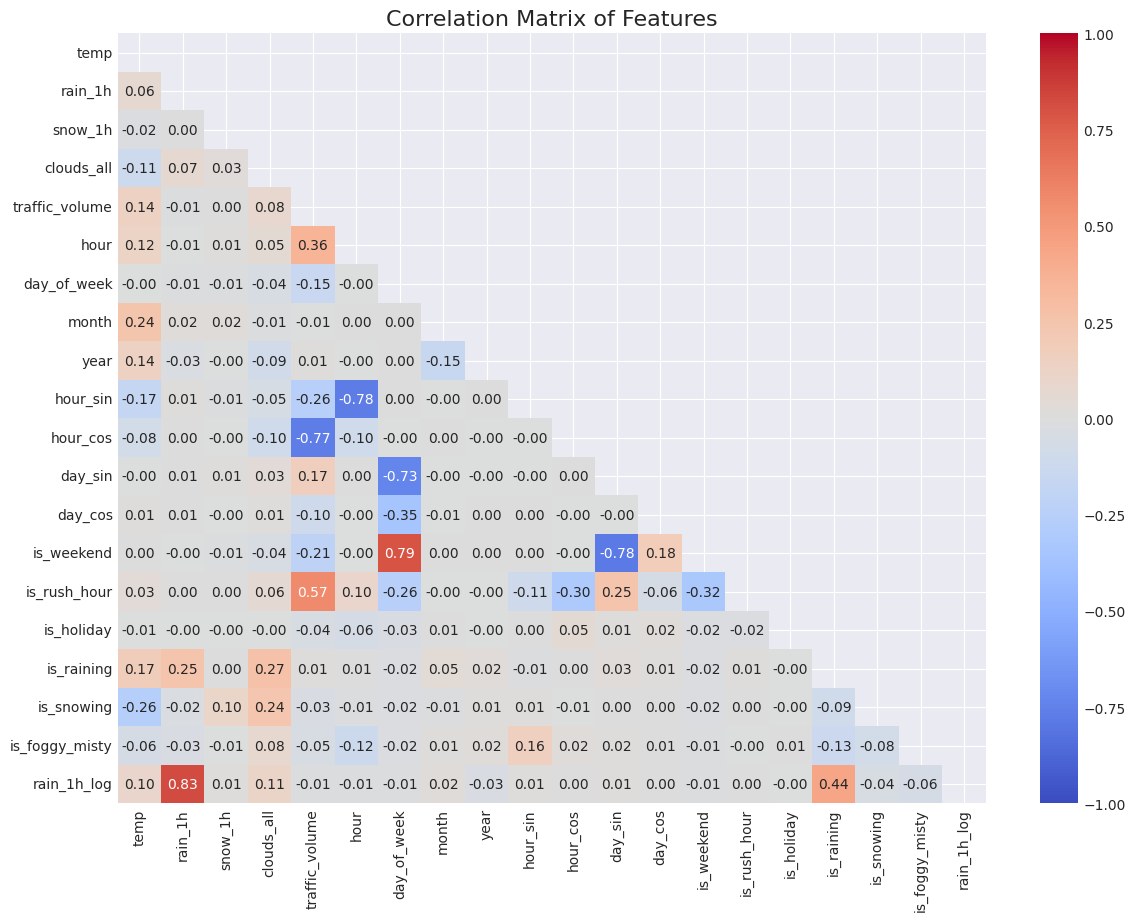

Pair of features with correlation greater than 0.1 in Descendent Order:
Correlation between rain_1h and rain_1h_log: 0.83
Correlation between day_of_week and is_weekend: 0.79
Correlation between day_sin and is_weekend: -0.78
Correlation between hour and hour_sin: -0.78
Correlation between hour_cos and traffic_volume: -0.77
Correlation between day_of_week and day_sin: -0.73
Correlation between is_rush_hour and traffic_volume: 0.57
Correlation between is_raining and rain_1h_log: 0.44
Correlation between hour and traffic_volume: 0.36
Correlation between day_cos and day_of_week: -0.35
Correlation between is_rush_hour and is_weekend: -0.32
Correlation between hour_cos and is_rush_hour: -0.30
Correlation between clouds_all and is_raining: 0.27
Correlation between is_snowing and temp: -0.26
Correlation between hour_sin and traffic_volume: -0.26
Correlation between day_of_week and is_rush_hour: -0.26
Correlation between day_sin and is_rush_hour: 0.25
Correlation between is_raining and rain_1h:

In [2]:
# Select numerical and boolean columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

print("Pair of features with correlation greater than 0.1 in Descendent Order:")
corr_pairs = [(col1, col2, corr.loc[col1, col2]) 
              for col1 in numeric_cols 
              for col2 in numeric_cols 
              if col1 < col2 and abs(corr.loc[col1, col2]) > 0.1]

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

for col1, col2, corr_val in corr_pairs:
    print(f"Correlation between {col1} and {col2}: {corr_val:.2f}")


### Initial Observations from Correlation:
1. **Cyclical Features**: We expect `hour_sin` and `hour_cos` to have interesting non-linear relationships with the target. 
2. **Multicollinearity Check**: Look closely at correlations between variables like `temp` and `month`, or `is_raining` and `rain_1h`. If they are highly correlated, we might drop one.

## 2. Analyzing New Engineered Features
Let's visually validate our engineered features to ensure they capture the variance in `traffic_volume`.

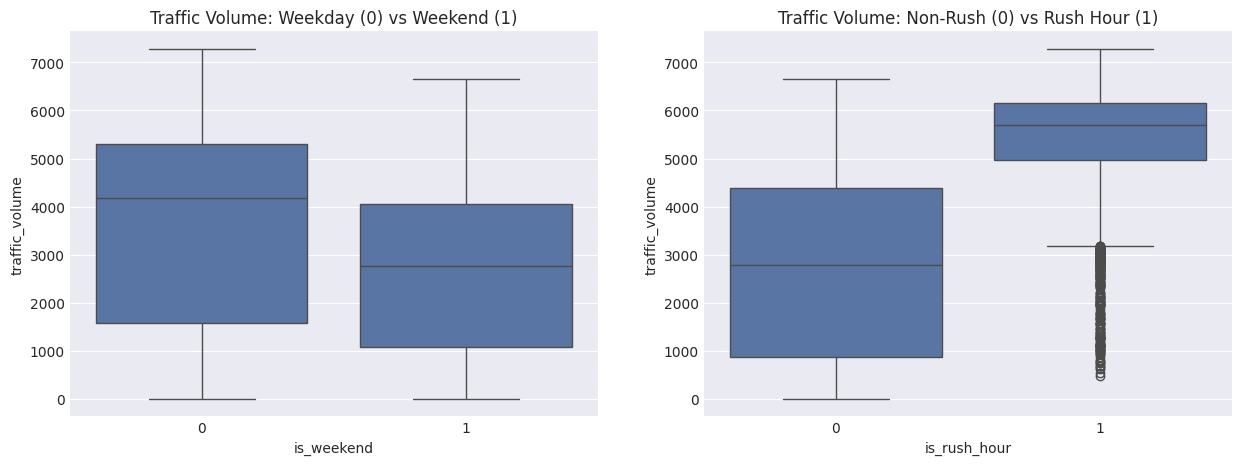

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='is_weekend', y='traffic_volume', ax=axes[0])
axes[0].set_title('Traffic Volume: Weekday (0) vs Weekend (1)')

sns.boxplot(data=df, x='is_rush_hour', y='traffic_volume', ax=axes[1])
axes[1].set_title('Traffic Volume: Non-Rush (0) vs Rush Hour (1)')

plt.show()

The boxplots should confirm our intuition: traffic is significantly lower on weekends, and much higher and concentrated during rush hours.

## 3. Weather Analysis: Raw Categories vs. Engineered Flags

We have the original `weather_main` categorical column and our custom boolean flags (`is_raining`, `is_snowing`, `is_foggy_misty`).

Let's check if the custom flags capture the essential weather information, which might allow us to drop the high-cardinality categorical strings.

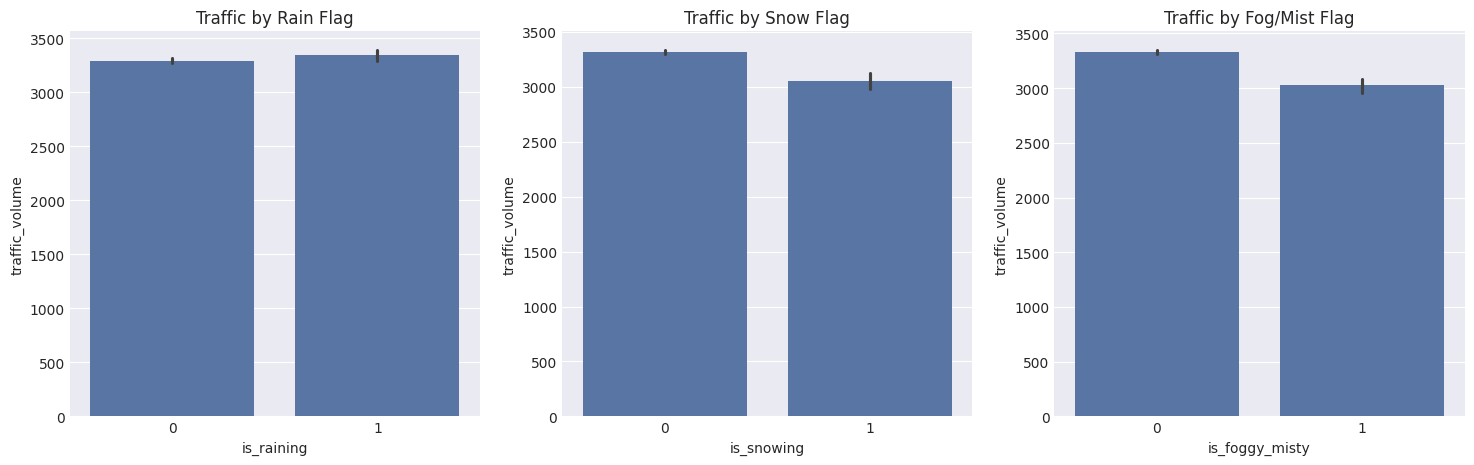

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='is_raining', y='traffic_volume', ax=axes[0])
axes[0].set_title('Traffic by Rain Flag')

sns.barplot(data=df, x='is_snowing', y='traffic_volume', ax=axes[1])
axes[1].set_title('Traffic by Snow Flag')

sns.barplot(data=df, x='is_foggy_misty', y='traffic_volume', ax=axes[2])
axes[2].set_title('Traffic by Fog/Mist Flag')

plt.show()

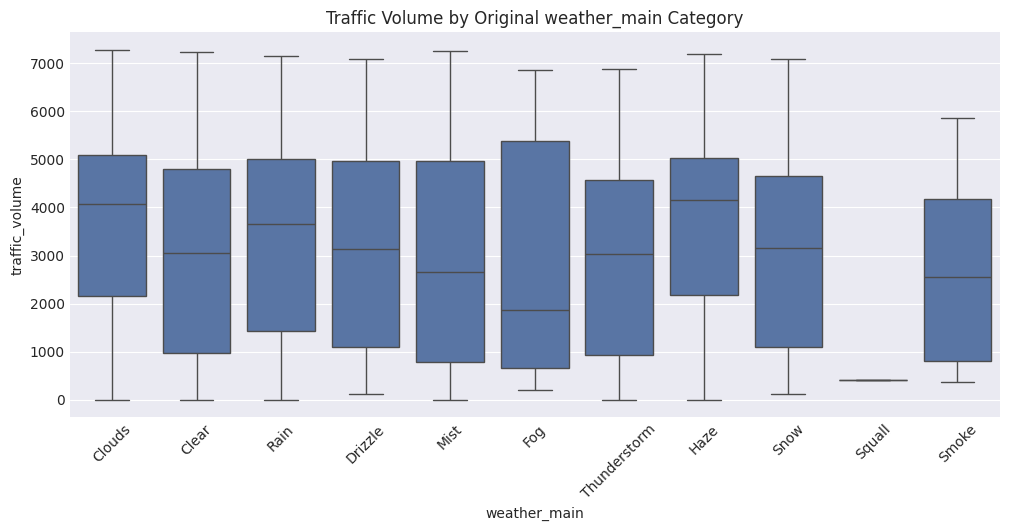

In [5]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='weather_main', y='traffic_volume')
plt.title('Traffic Volume by Original weather_main Category')
plt.xticks(rotation=45)
plt.show()

## 4. Feature Selection Decisions

Based on the EDA above, we must decide which columns to keep for the model.

**Candidates for removal:**
1. `holiday`: Mostly `NaN` or "None". We created `is_holiday` which is a clean binary representation. We can drop `holiday`.
2. `weather_description`: High cardinality, lots of typos/redundancies. We captured its essence in `is_raining`, `is_snowing`, and `is_foggy_misty`. We can drop `weather_description`.
3. `weather_main`: If we decide our boolean flags are sufficient, we can drop `weather_main` entirely to avoid One-Hot Encoding and simplify the model. Alternatively, we can keep it and One-Hot Encode it, but drop the boolean flags. We will evaluate this trade-off.
4. `hour`, `day_of_week`, `month`, `year`: We have `hour_sin`, `hour_cos`, `day_sin`, `day_cos`. We should likely drop the raw integer representations to prevent the model from learning linear relationships on cyclic data.

**Next Step for the User:**
Run this notebook, interpret the graphs, and confirm the list of features to drop in the final ML preparation script.


## 5. Temporal Timeline & Data Splitting Strategy

Because our dataset is a **Time Series** (hourly traffic volume over several years), we must be extremely careful about how we split the data into Training, Validation (Dev), and Testing sets. 

### Why Standard Random Splitting (e.g., K-Fold or `train_test_split`) is Risky
Standard Machine Learning practices often involve randomly shuffling the data and taking a percentage (like 80/20) or using K-Fold Cross Validation. However, **randomly shuffling time series data destroys the temporal aspect and leads to Data Leakage**. 
If you randomly shuffle, you might train a model on data from December 2017 to predict traffic in June 2016. In the real world, you cannot use future data to predict the past. Models like ARIMA or SARIMA strictly require continuous, unbroken temporal sequences. Even non-temporal models (like XGBoost, Random Forest, or Linear Regression) will suffer from unrealistic performance metrics if evaluated on shuffled time data because they will implicitly "peek" into the future.

### How Different Models React to Splitting
1.  **Classical Time Series (ARIMA / SARIMA):** 
    These models require an absolutely continuous time sequence without any gaps. They predict $t$ based strictly on $t-1, t-2$, etc. If we split the data, we must do a single chronological cut (e.g., Train on 2012-2016, Test on 2017). They cannot handle random K-Folds.
2.  **Machine Learning (XGBoost, Random Forest, Linear Regression, MLP):** 
    Because we engineered the time into explicit features (`hour_cos`, `day_sin`, `is_weekend`, etc.), these models treat each row independently and do not inherently look at the previous row. However, to evaluate them fairly against real-world conditions, we still must test them on a "future" block of data they haven't seen. 

### Best Practice Decision: Chronological Split (Holdout) or TimeSeriesSplit
To maintain fairness and avoid leakage:
1.  **Final Split:** We will sort the dataset by `date_time` in ascending order.
2.  **Train/Dev/Test:** We will slice the dataset chronologically. For example:
    *   **Train Set:** The first 70% of the timeline.
    *   **Validation (Dev) Set:** The next 15% of the timeline (used for hyperparameter tuning).
    *   **Test Set:** The final 15% of the timeline (used strictly for final evaluation).

Let's visualize the timeline of our current dataset to see how these splits will look.


Dataset Start Date: 2012-10-02 09:00:00
Dataset End Date:   2018-09-30 23:00:00
Total Hours/Rows:   42880


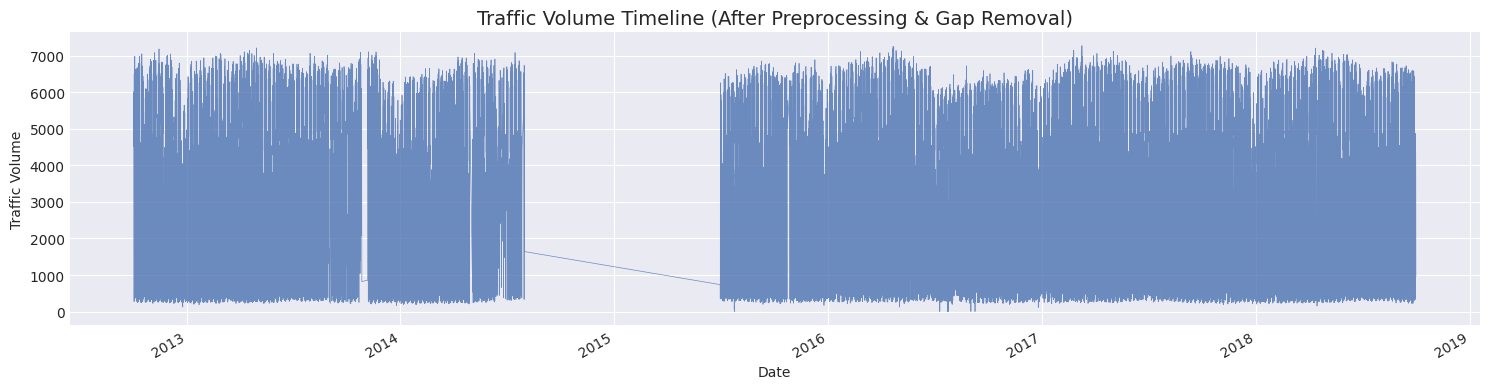

In [6]:

# Check the temporal range of the dataset
print(f"Dataset Start Date: {df.index.min()}")
print(f"Dataset End Date:   {df.index.max()}")
print(f"Total Hours/Rows:   {len(df)}")

# Create a plot showing the continuous timeline
plt.figure(figsize=(15, 4))
df['traffic_volume'].plot(linewidth=0.5, alpha=0.8)
plt.title('Traffic Volume Timeline (After Preprocessing & Gap Removal)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Traffic Volume')
plt.tight_layout()
plt.show()



As we can see, after dropping the massive critical gap (August 2014 – June 2015) during preprocessing, we have two large continuous blocks of data. 

**Chronological Split Implementation:**
To implement the 70/15/15 split, we will use Python's indexing on the chronologically sorted dataframe, ensuring no future data leaks into the past during training.



## 6. Gap Analysis & The "Missing" Data Mystery

If we look closely at the timeline plot above, we see straight lines connecting distant points. The most obvious one is between August 2014 and June 2015 (the critical period we decided to drop). But there also appear to be smaller "jumps". 

Let's investigate the time index of our `clean_traffic_data.csv` to see what exactly happened during the preprocessing pipeline.


In [11]:

# Calculate the time difference between consecutive rows
time_diffs = df.index.to_series().diff()

# Find all gaps where the jump is strictly greater than 1 hour
large_gaps = time_diffs[time_diffs > pd.Timedelta(hours=1)]

print(f"Total number of gaps strictly greater than 1 hour: {len(large_gaps)}")
print("\nTop 10 largest gaps in the dataset:")
print(large_gaps.nlargest(20))


Total number of gaps strictly greater than 1 hour: 182

Top 10 largest gaps in the dataset:
date_time
2015-07-01 00:00:00   334 days 01:00:00
2013-11-06 04:00:00    10 days 03:00:00
2014-05-04 05:00:00     4 days 21:00:00
2015-10-27 08:00:00     3 days 21:00:00
2014-07-30 09:00:00     2 days 17:00:00
2013-09-01 23:00:00     1 days 23:00:00
2013-09-04 08:00:00     1 days 06:00:00
2013-01-30 01:00:00     1 days 01:00:00
2013-10-02 23:00:00     1 days 00:00:00
2014-06-17 09:00:00     1 days 00:00:00
2013-10-01 21:00:00     0 days 22:00:00
2014-06-30 19:00:00     0 days 22:00:00
2014-07-25 00:00:00     0 days 22:00:00
2014-06-24 09:00:00     0 days 21:00:00
2013-10-23 05:00:00     0 days 17:00:00
2013-09-07 20:00:00     0 days 15:00:00
2014-06-22 20:00:00     0 days 15:00:00
2013-08-27 14:00:00     0 days 14:00:00
2014-06-17 23:00:00     0 days 14:00:00
2015-10-17 03:00:00     0 days 14:00:00
Name: date_time, dtype: timedelta64[us]



### What happened to the gaps?

During our preprocessing pipeline (`src/run_pipeline.py` and `src/data/preprocessing.py`), we did the following:
1.  **Reindexed** the entire timeline from 2012 to 2018. This forced the dataset to have a continuous row for every single hour, filling the missing hours with `NaN`.
2.  **Imputed Small Gaps**: We applied linear interpolation **only** for gaps of $\le 2$ hours.
3.  **Dropped Target-Missing Rows**: In `run_pipeline.py`, we executed `df.dropna(subset=["traffic_volume"])`.

**The result:** Any gap that was 3 hours or longer (including the massive 334-day critical gap in 2014-2015, and the 10-day gap in Nov 2013) was left as `NaN` during step 2, and subsequently **completely deleted** from the dataset in step 3. 

This means there are exactly **182 structural "jumps"** in our final dataset where the time skips forward by more than 1 hour. Matplotlib simply draws a straight line connecting the data points across these jumps.

### Implications for Modeling
Because our time index is **broken 182 times**, we **cannot** use classical autoregressive time series models like **ARIMA or SARIMA**. Those models strictly require a perfectly continuous timeline. 

However, this is perfectly fine for **Machine Learning Models** (XGBoost, Random Forest, Linear Regression, Neural Networks). Because we engineered the time explicitly into the columns (`hour_cos`, `day_sin`, `is_weekend`, `is_rush_hour`), the ML algorithms do not care what the "previous row" was. They treat each row independently. 

**Final Decision:** We will proceed exclusively with Machine Learning algorithms (avoiding ARIMA/SARIMA). We will use a **Chronological Holdout Split** (e.g., Train on the first 70% of rows, regardless of the gaps, and Test on the last 15% of rows) to prevent data leakage.
